# Exploratory Data Analysis of Large-Scale Industry Performance Dataset
## NextHikes IT Solutions — Project Submission
**Author:** Dhiraj Sharma  
**Submission Date:** 10th June, 2026  
**Dataset:** INDUSTRY.csv — 15,000 records × 12 columns


## 1. Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Global styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

In [27]:
import pandas as pd

df = pd.read_csv(r"C:\Users\dhira\Downloads\Project 4 B\INDUSTRY.csv")
print("Shape:", df.shape)
df.head()
print("Shape:", df.shape)
df.head()


Shape: (15000, 12)
Shape: (15000, 12)


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


## 3. Dataset Overview

In [28]:
print("Columns:", df.columns.tolist())
print()
print("Data Types:")
print(df.dtypes)
print()
print("Null Values:")
print(df.isnull().sum())


Columns: ['id', 'company_name', 'industry', 'country', 'employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'created_date', 'region']

Data Types:
id                          int64
company_name                  str
industry                      str
country                       str
employee_count              int64
annual_revenue_million    float64
profit_margin_percent     float64
founded_year                int64
customer_count              int64
market_rating             float64
created_date                  str
region                        str
dtype: object

Null Values:
id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64


In [29]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
id,15000.0,7500.50,4330.27,1.00,3750.75,7500.50,11250.25,15000.00
employee_count,15000.0,2606.86,1430.56,100.00,1379.00,2587.00,3839.00,5099.00
annual_revenue_million,15000.0,549.73,288.24,50.16,299.92,543.92,797.57,1049.96
profit_margin_percent,15000.0,25.01,11.53,5.00,15.05,24.91,35.10,45.00
founded_year,15000.0,2004.37,8.61,1990.00,1997.00,2004.00,2012.00,2019.00
customer_count,15000.0,50449.25,28744.64,500.00,25676.25,50726.50,75271.25,100495.00
market_rating,15000.0,2.51,1.45,0.00,1.20,2.50,3.80,5.00


## 4. Univariate Analysis
### 4.1 Numerical Variables — Descriptive Statistics + Skewness & Kurtosis


In [30]:
num_cols = ['employee_count', 'annual_revenue_million',
            'profit_margin_percent', 'founded_year',
            'customer_count', 'market_rating']

stats_df = pd.DataFrame({
    'Mean':     df[num_cols].mean(),
    'Median':   df[num_cols].median(),
    'Std Dev':  df[num_cols].std(),
    'Min':      df[num_cols].min(),
    'Max':      df[num_cols].max(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
}).round(3)

stats_df


,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
employee_count,2606.862,2587.00,1430.563,100.00,5099.00,0.002,-1.188
annual_revenue_million,549.733,543.92,288.244,50.16,1049.96,0.027,-1.187
profit_margin_percent,25.012,24.91,11.526,5.00,45.00,0.003,-1.203
founded_year,2004.374,2004.00,8.607,1990.00,2019.00,0.021,-1.190
customer_count,50449.252,50726.50,28744.639,500.00,100495.00,-0.005,-1.195
market_rating,2.514,2.50,1.448,0.00,5.00,-0.020,-1.206


### 4.2 Histograms — Numerical Variables

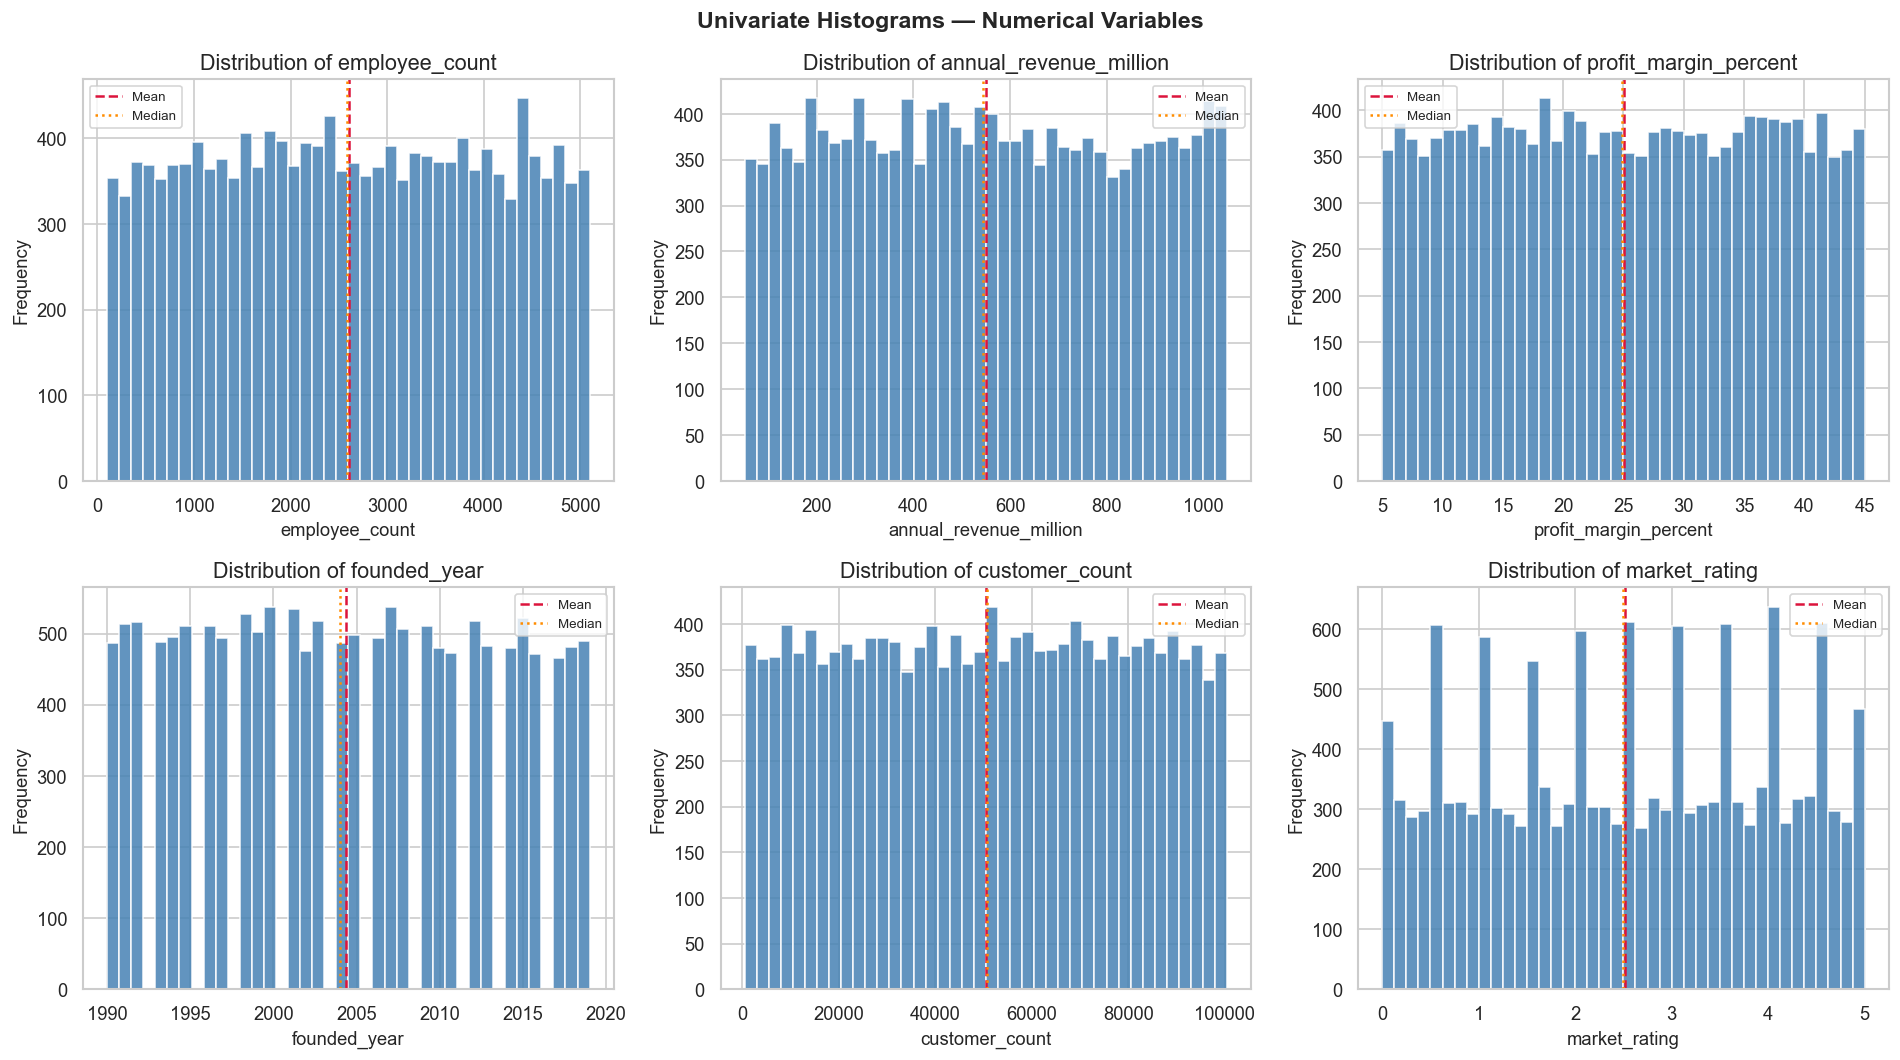

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='darkorange', linestyle=':', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Histograms — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univariate_histograms.png', bbox_inches='tight')
plt.show()


### 4.3 Categorical Variables — Frequency Distribution

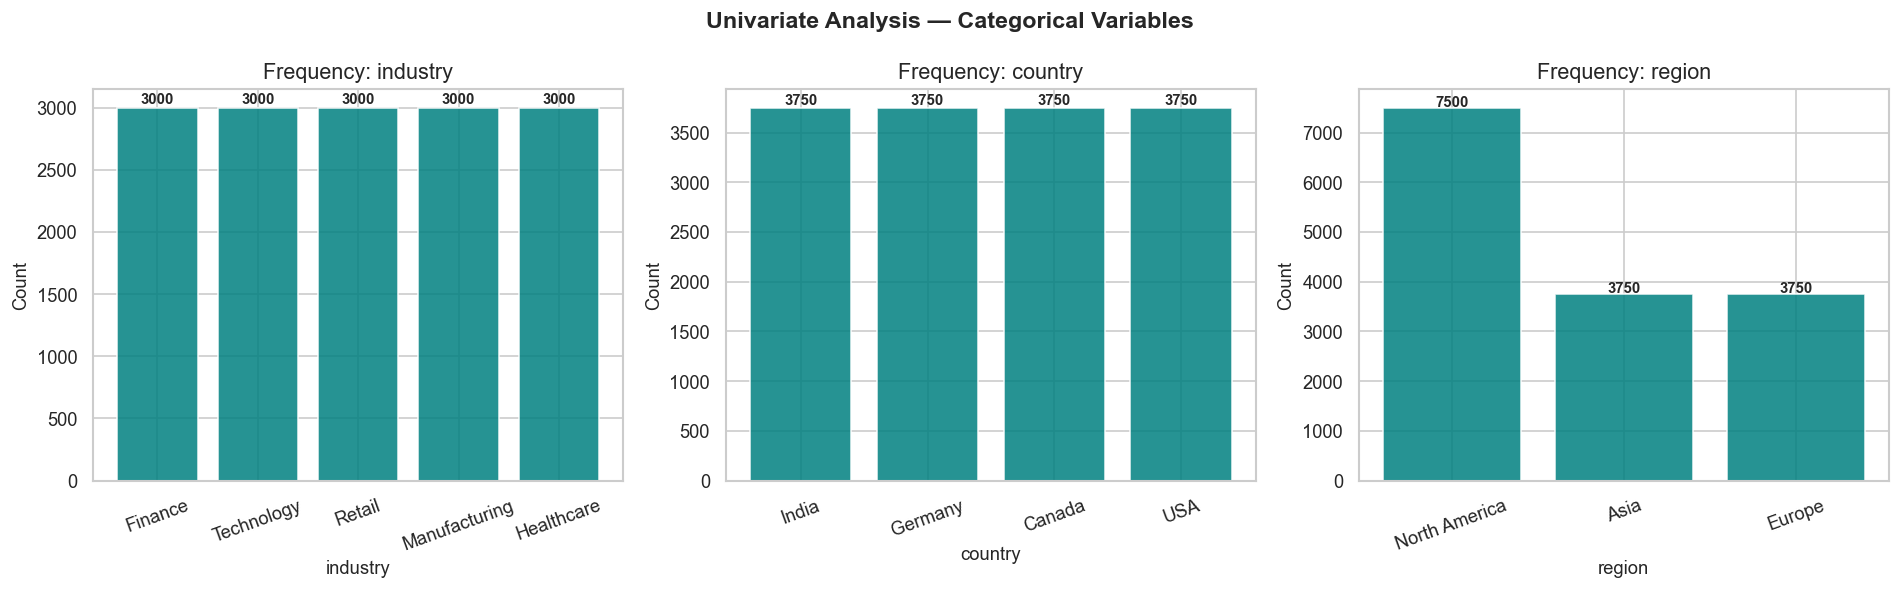

In [32]:
cat_cols = ['industry', 'country', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='teal', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Frequency: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 30, str(v), ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Univariate Analysis — Categorical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univariate_categorical.png', bbox_inches='tight')
plt.show()


In [33]:
# Print counts
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- industry ---
industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

--- country ---
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

--- region ---
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64



## 5. Outlier Detection

### 5.1 Boxplots

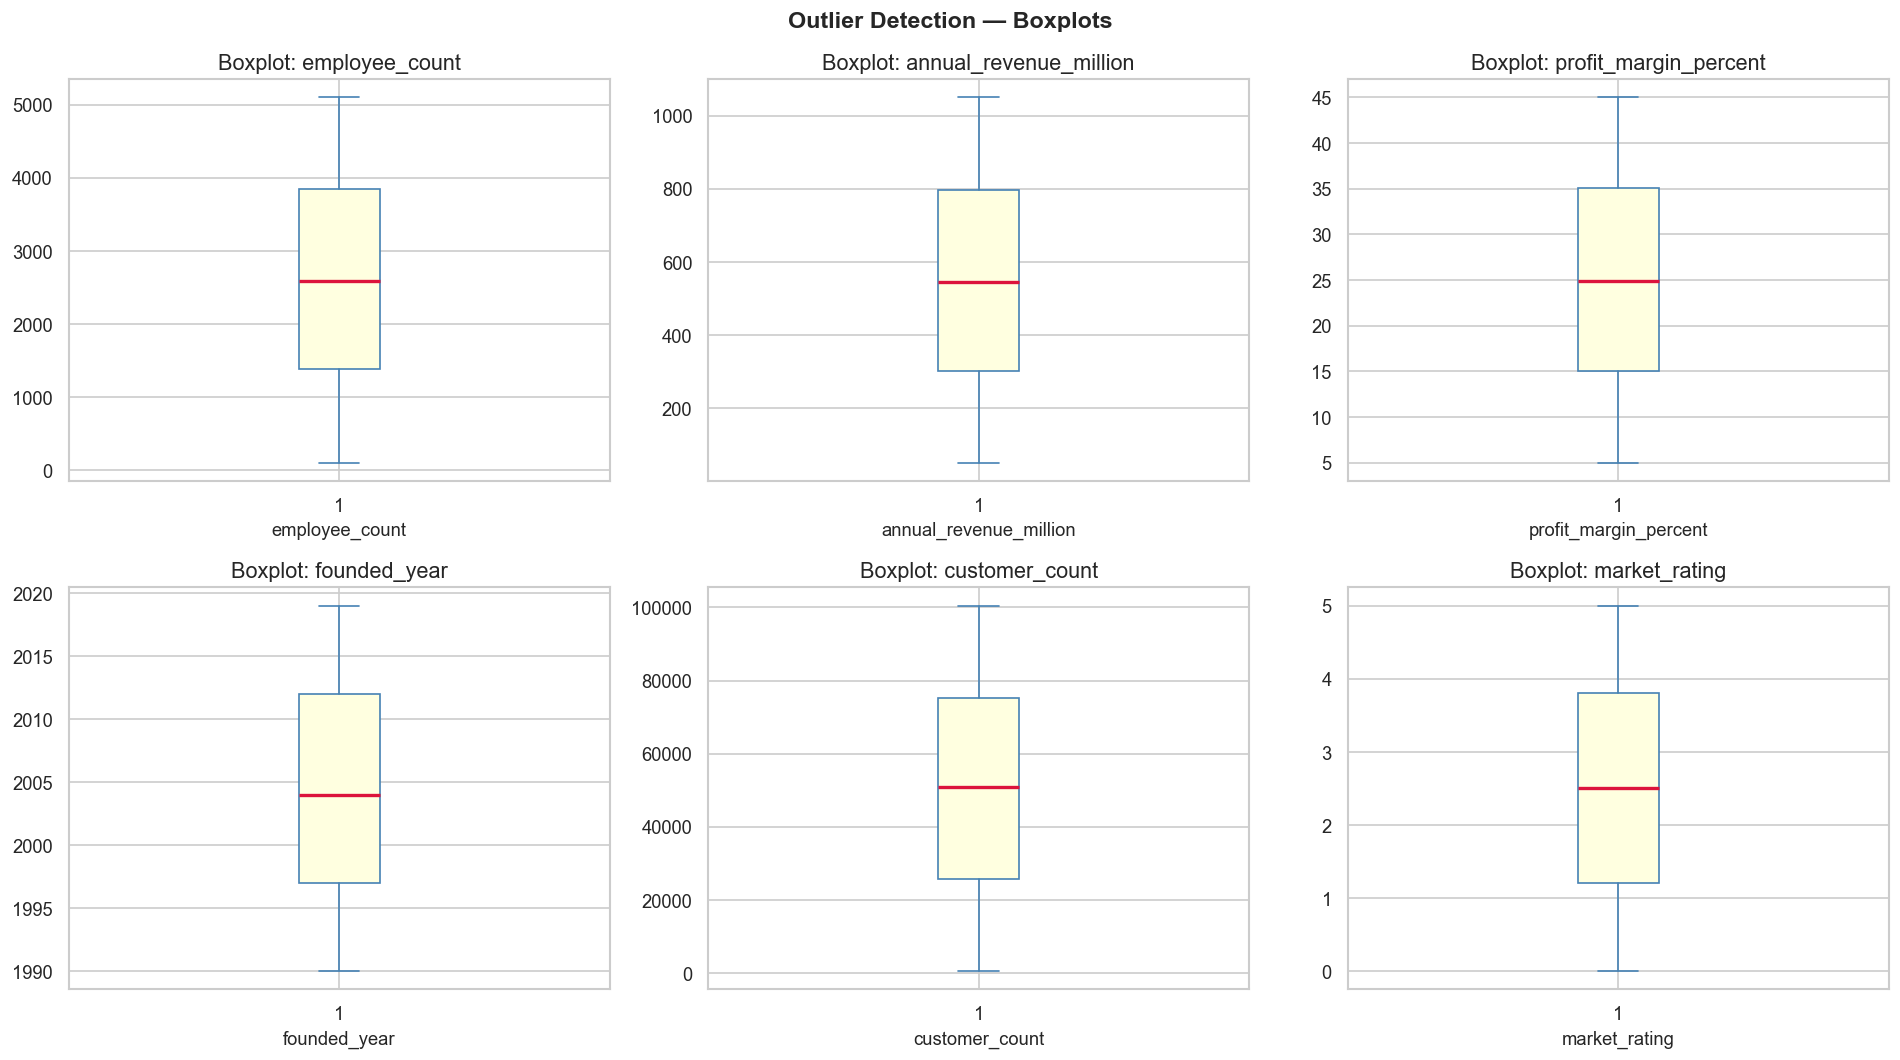

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightyellow', color='steelblue'),
                    medianprops=dict(color='crimson', linewidth=2),
                    whiskerprops=dict(color='steelblue'),
                    capprops=dict(color='steelblue'),
                    flierprops=dict(marker='o', color='red', alpha=0.3, markersize=4))
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Outlier Detection — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_outliers.png', bbox_inches='tight')
plt.show()


### 5.2 IQR Method — Outlier Count

In [35]:
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))


                Column       Q1       Q3      IQR  Lower Bound  Upper Bound  Outlier Count
        employee_count  1379.00  3839.00  2460.00     -2311.00      7529.00              0
annual_revenue_million   299.92   797.57   497.66      -446.57      1544.05              0
 profit_margin_percent    15.05    35.10    20.05       -15.03        65.18              0
          founded_year  1997.00  2012.00    15.00      1974.50      2034.50              0
        customer_count 25676.25 75271.25 49595.00    -48716.25    149663.75              0
         market_rating     1.20     3.80     2.60        -2.70         7.70              0


### 5.3 Z-Score Method

In [36]:
z_scores = np.abs(stats.zscore(df[num_cols]))
z_outlier_counts = (z_scores > 3).sum(axis=0)
z_result = pd.DataFrame({'Column': num_cols, 'Outliers (|Z| > 3)': z_outlier_counts})
print(z_result.to_string(index=False))
print()
print("Note: Outliers retained — they represent genuine large-scale multinational organizations.")


                Column  Outliers (|Z| > 3)
        employee_count                   0
annual_revenue_million                   0
 profit_margin_percent                   0
          founded_year                   0
        customer_count                   0
         market_rating                   0

Note: Outliers retained — they represent genuine large-scale multinational organizations.


## 6. Bivariate Analysis

### 6.1 Numerical vs Numerical — Scatter Plots

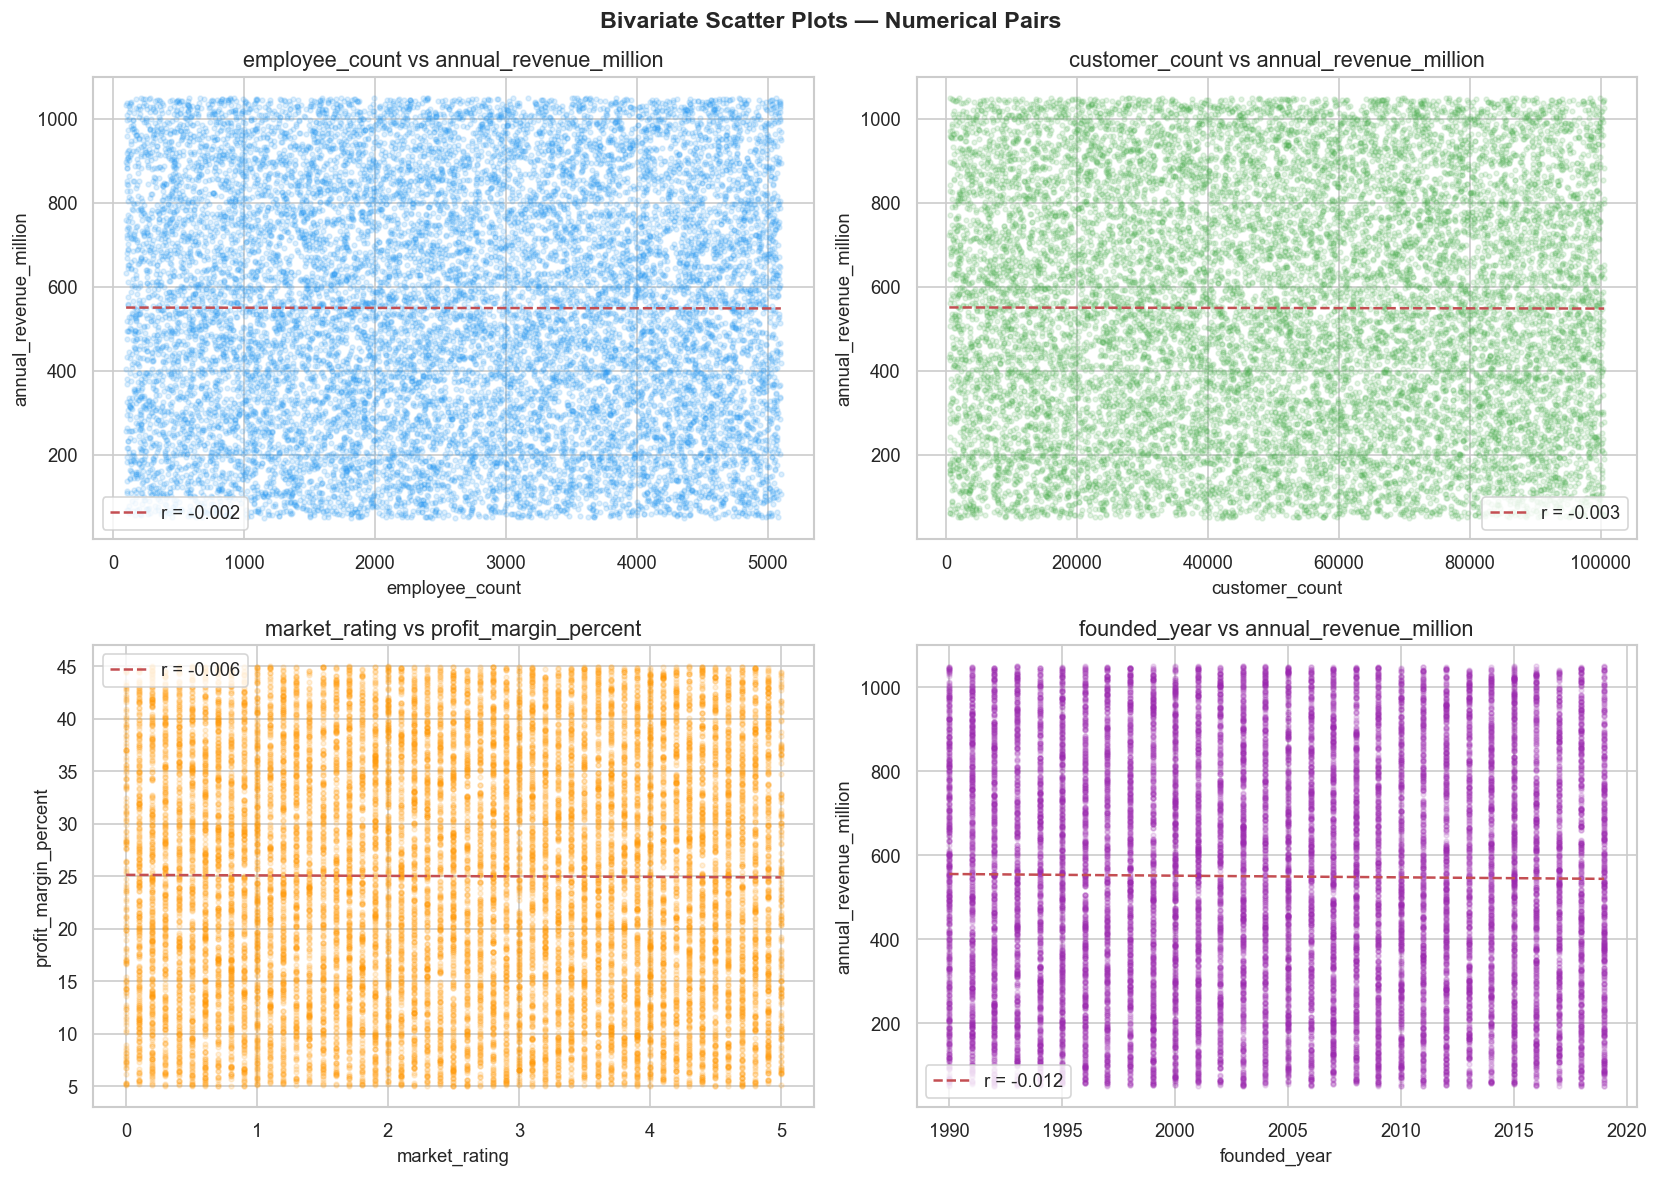

In [37]:
pairs = [
    ('employee_count', 'annual_revenue_million'),
    ('customer_count', 'annual_revenue_million'),
    ('market_rating', 'profit_margin_percent'),
    ('founded_year', 'annual_revenue_million')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.15, s=8, color=colors[i])
    m, b = np.polyfit(df[x], df[y], 1)
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    axes[i].plot(xline, m*xline + b, 'r--', linewidth=1.5, label=f'r = {df[x].corr(df[y]):.3f}')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')
    axes[i].legend()

plt.suptitle('Bivariate Scatter Plots — Numerical Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bivariate_scatter.png', bbox_inches='tight')
plt.show()


### 6.2 Numerical vs Categorical — Bar Charts

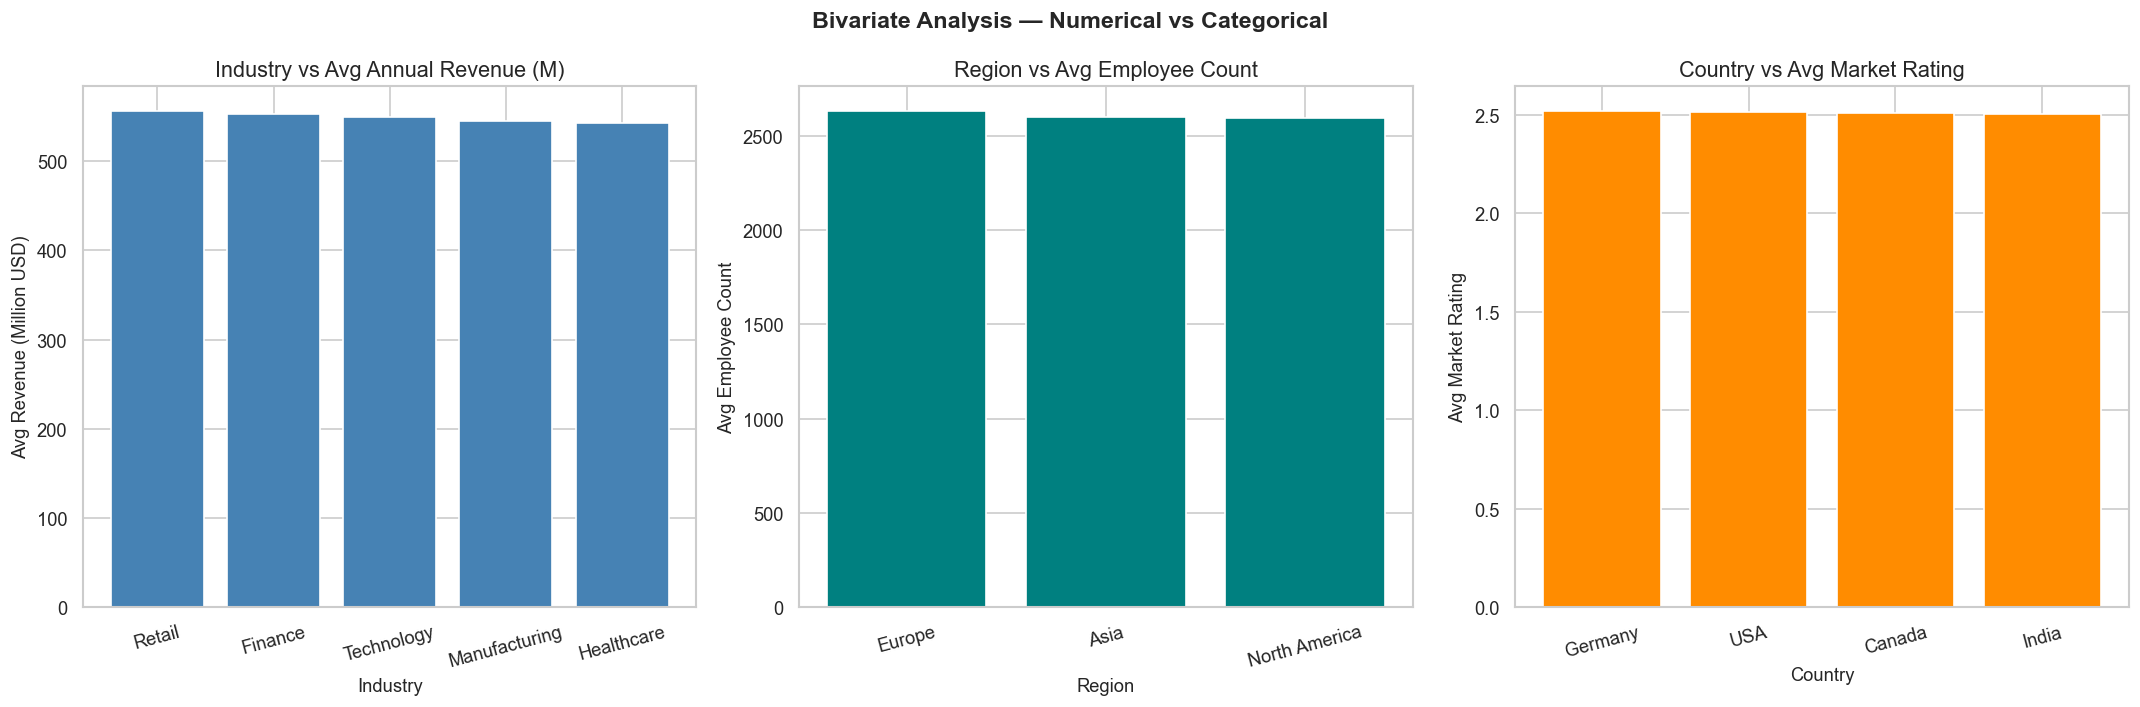

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Industry vs avg annual revenue
ind_rev = df.groupby('industry')['annual_revenue_million'].mean().sort_values(ascending=False)
axes[0].bar(ind_rev.index, ind_rev.values, color='steelblue', edgecolor='white')
axes[0].set_title('Industry vs Avg Annual Revenue (M)')
axes[0].set_xlabel('Industry')
axes[0].set_ylabel('Avg Revenue (Million USD)')
axes[0].tick_params(axis='x', rotation=15)

# Region vs avg employee count
reg_emp = df.groupby('region')['employee_count'].mean().sort_values(ascending=False)
axes[1].bar(reg_emp.index, reg_emp.values, color='teal', edgecolor='white')
axes[1].set_title('Region vs Avg Employee Count')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Avg Employee Count')
axes[1].tick_params(axis='x', rotation=15)

# Country vs avg market rating
ctr_rating = df.groupby('country')['market_rating'].mean().sort_values(ascending=False)
axes[2].bar(ctr_rating.index, ctr_rating.values, color='darkorange', edgecolor='white')
axes[2].set_title('Country vs Avg Market Rating')
axes[2].set_xlabel('Country')
axes[2].set_ylabel('Avg Market Rating')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Bivariate Analysis — Numerical vs Categorical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bivariate_categorical.png', bbox_inches='tight')
plt.show()


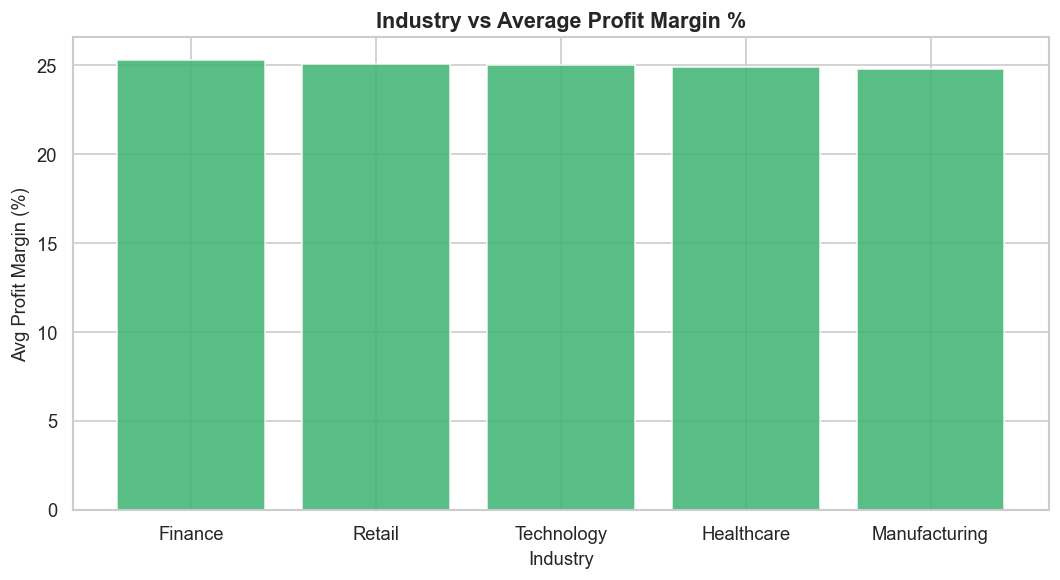

industry
Finance          25.303310
Retail           25.085197
Technology       25.031367
Healthcare       24.878077
Manufacturing    24.762147
Name: profit_margin_percent, dtype: float64


In [39]:
# Industry vs avg profit margin
ind_pm = df.groupby('industry')['profit_margin_percent'].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
plt.bar(ind_pm.index, ind_pm.values, color='mediumseagreen', edgecolor='white', alpha=0.85)
plt.title('Industry vs Average Profit Margin %', fontsize=13, fontweight='bold')
plt.xlabel('Industry')
plt.ylabel('Avg Profit Margin (%)')
plt.tight_layout()
plt.savefig('industry_profit_margin.png', bbox_inches='tight')
plt.show()
print(ind_pm)


## 7. Correlation Matrix Analysis

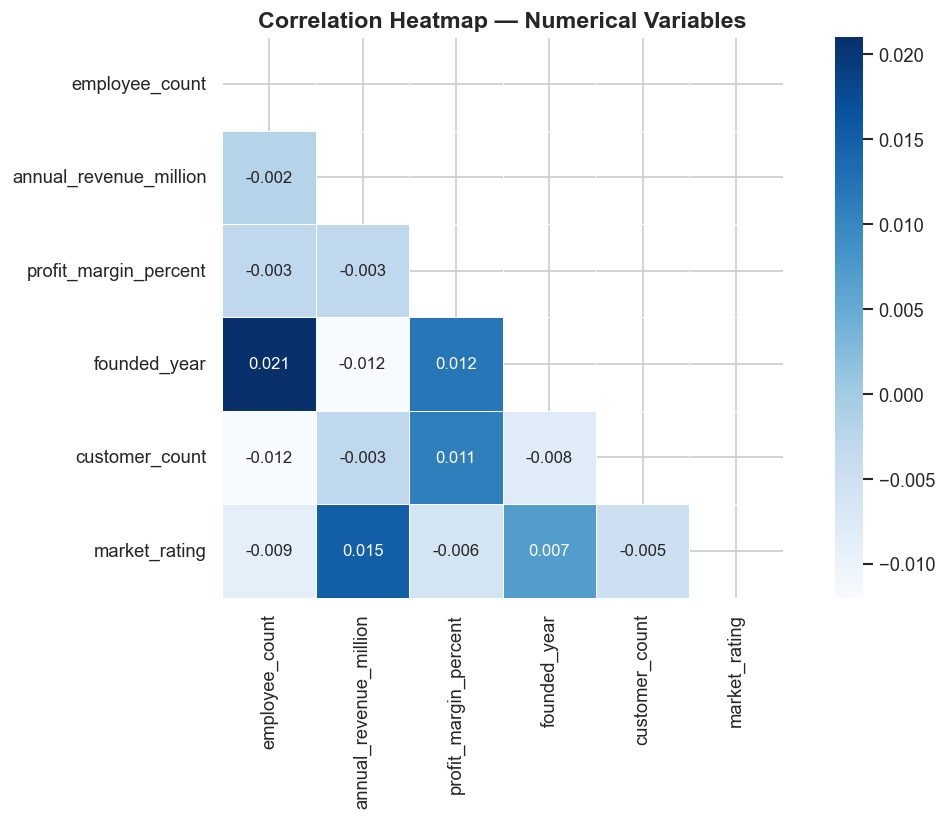

Correlation Matrix:
                        employee_count  annual_revenue_million  \
employee_count                   1.000                  -0.002   
annual_revenue_million          -0.002                   1.000   
profit_margin_percent           -0.003                  -0.003   
founded_year                     0.021                  -0.012   
customer_count                  -0.012                  -0.003   
market_rating                   -0.009                   0.015   

                        profit_margin_percent  founded_year  customer_count  \
employee_count                         -0.003         0.021          -0.012   
annual_revenue_million                 -0.003        -0.012          -0.003   
profit_margin_percent                   1.000         0.012           0.011   
founded_year                            0.012         1.000          -0.008   
customer_count                          0.011        -0.008           1.000   
market_rating                          -0.0

In [40]:
corr_matrix = df[num_cols].corr().round(3)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    square=True,
    mask=mask,
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Correlation Matrix:")
print(corr_matrix)


## 8. Multivariate Analysis

### 8.1 Industry × Revenue × Employee Count

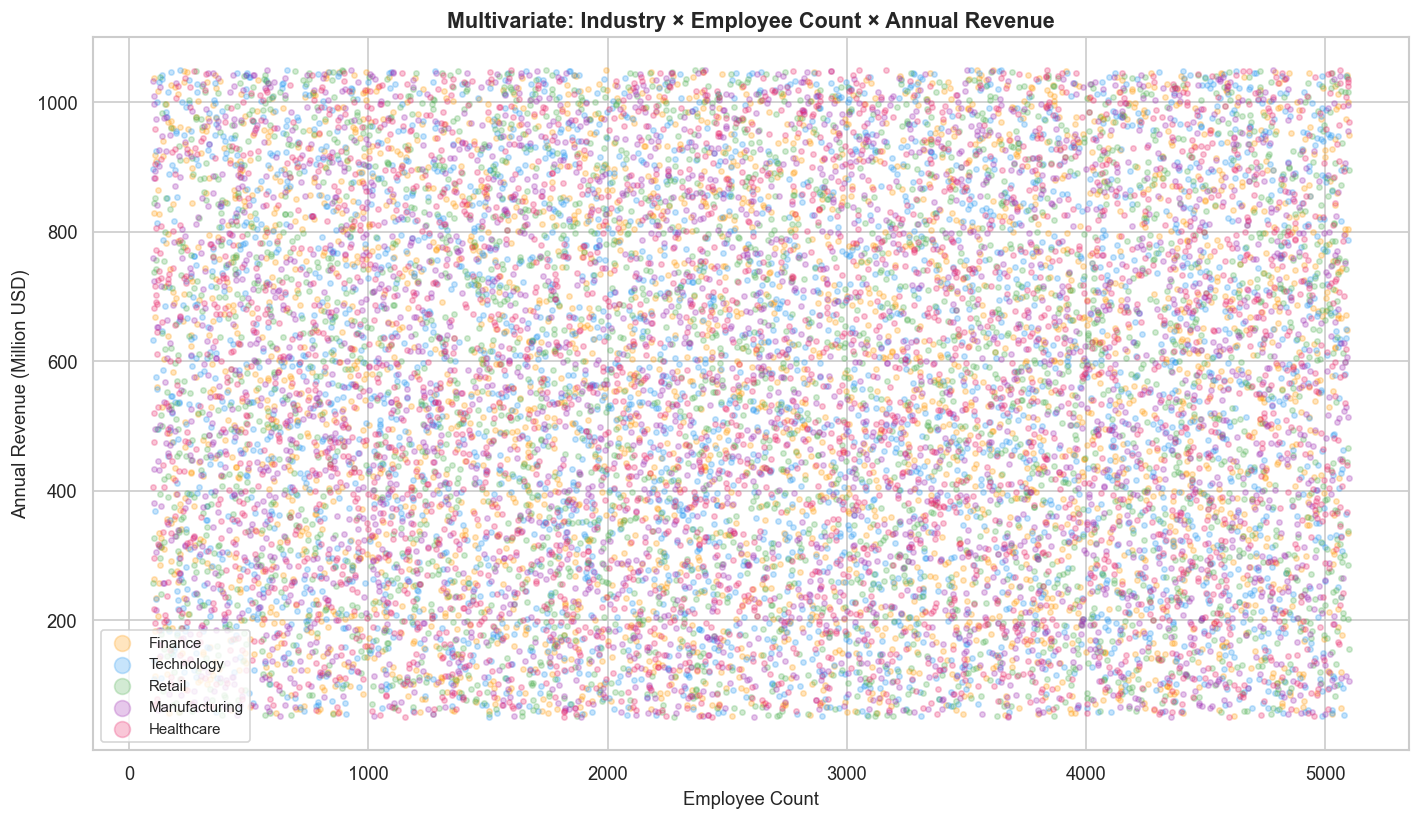

In [41]:
plt.figure(figsize=(12, 7))
industries = df['industry'].unique()
colors_map = {'Technology':'#2196F3','Retail':'#4CAF50','Finance':'#FF9800',
              'Healthcare':'#E91E63','Manufacturing':'#9C27B0'}

for ind in industries:
    subset = df[df['industry'] == ind]
    plt.scatter(subset['employee_count'], subset['annual_revenue_million'],
                alpha=0.25, s=10, label=ind, color=colors_map.get(ind, 'grey'))

plt.xlabel('Employee Count')
plt.ylabel('Annual Revenue (Million USD)')
plt.title('Multivariate: Industry × Employee Count × Annual Revenue', fontsize=13, fontweight='bold')
plt.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig('multivariate_industry_rev_emp.png', bbox_inches='tight')
plt.show()


### 8.2 Region × Market Rating × Profit Margin

Region-wise Avg Market Rating and Profit Margin:
               market_rating  profit_margin_percent
region                                             
Asia                   2.504                 25.078
Europe                 2.522                 25.019
North America          2.515                 24.976



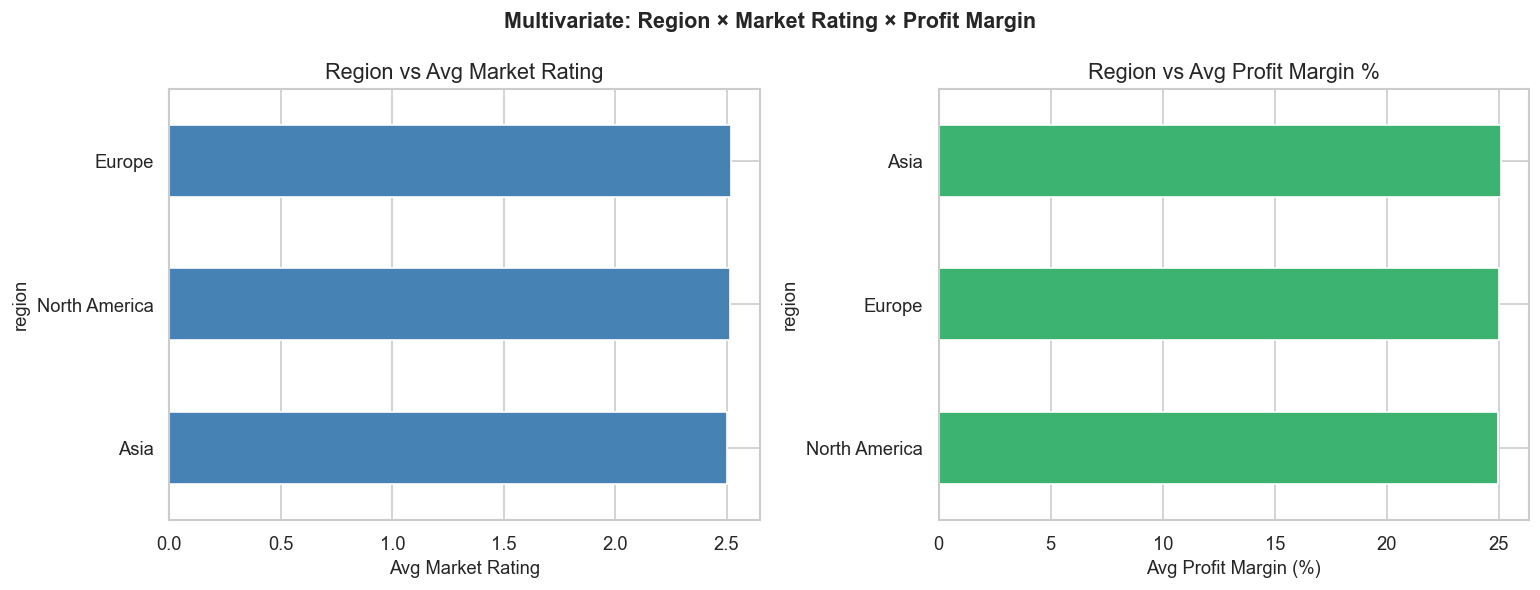

In [42]:
region_stats = df.groupby('region')[['market_rating', 'profit_margin_percent']].mean().round(3)
print("Region-wise Avg Market Rating and Profit Margin:")
print(region_stats)
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
region_stats['market_rating'].sort_values().plot(kind='barh', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Region vs Avg Market Rating')
axes[0].set_xlabel('Avg Market Rating')

region_stats['profit_margin_percent'].sort_values().plot(kind='barh', ax=axes[1],
    color='mediumseagreen', edgecolor='white')
axes[1].set_title('Region vs Avg Profit Margin %')
axes[1].set_xlabel('Avg Profit Margin (%)')

plt.suptitle('Multivariate: Region × Market Rating × Profit Margin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multivariate_region.png', bbox_inches='tight')
plt.show()


### 8.3 Industry × Founded Year × Revenue

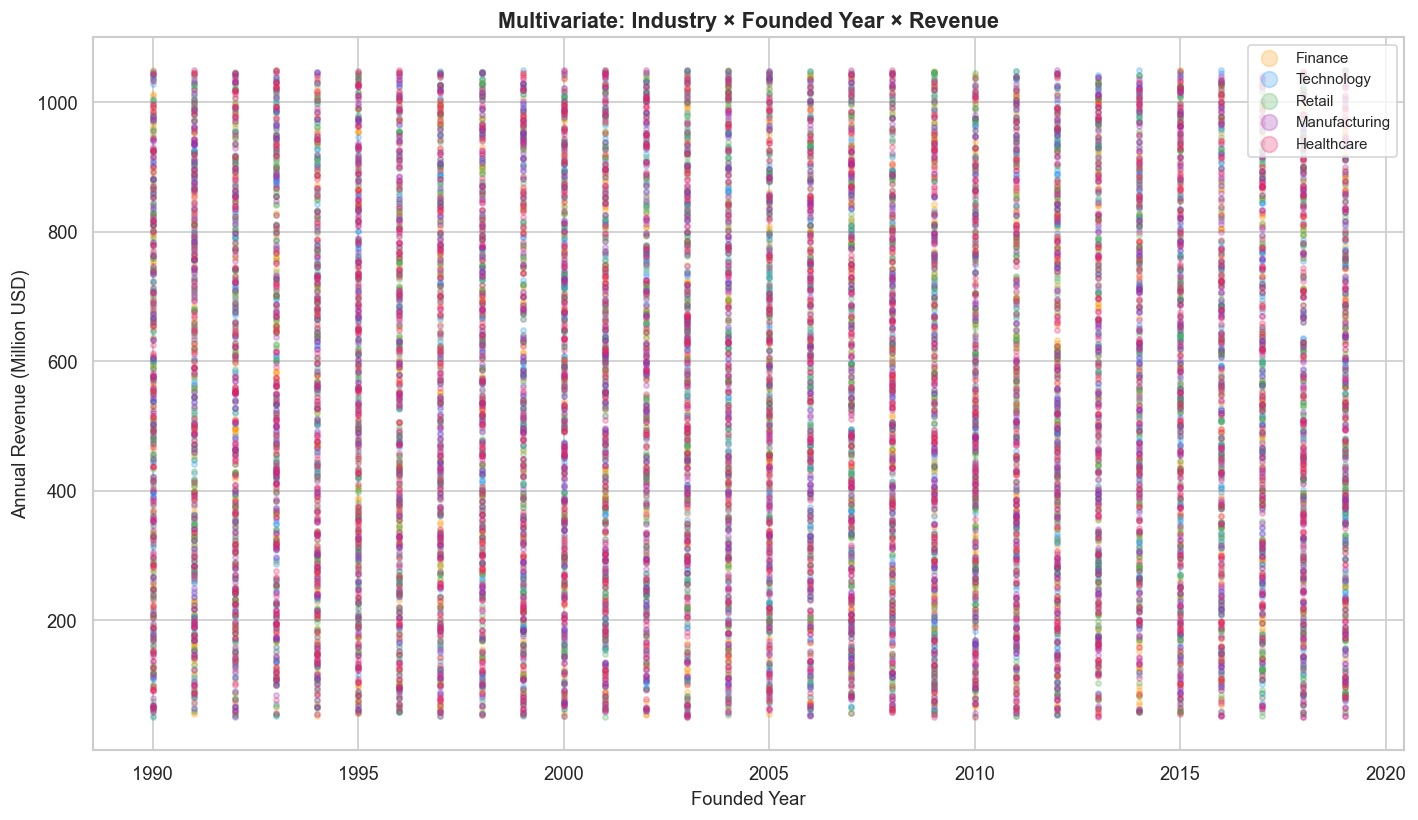

In [43]:
plt.figure(figsize=(12, 7))
for ind in industries:
    subset = df[df['industry'] == ind]
    plt.scatter(subset['founded_year'], subset['annual_revenue_million'],
                alpha=0.25, s=10, label=ind, color=colors_map.get(ind, 'grey'))

plt.xlabel('Founded Year')
plt.ylabel('Annual Revenue (Million USD)')
plt.title('Multivariate: Industry × Founded Year × Revenue', fontsize=13, fontweight='bold')
plt.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig('multivariate_founded_rev.png', bbox_inches='tight')
plt.show()


### 8.4 Country × Customer Count × Revenue

         customer_count  annual_revenue_million
country                                        
Canada         51453.22                  548.38
Germany        50197.03                  545.78
India          49993.63                  551.87
USA            50153.13                  552.91


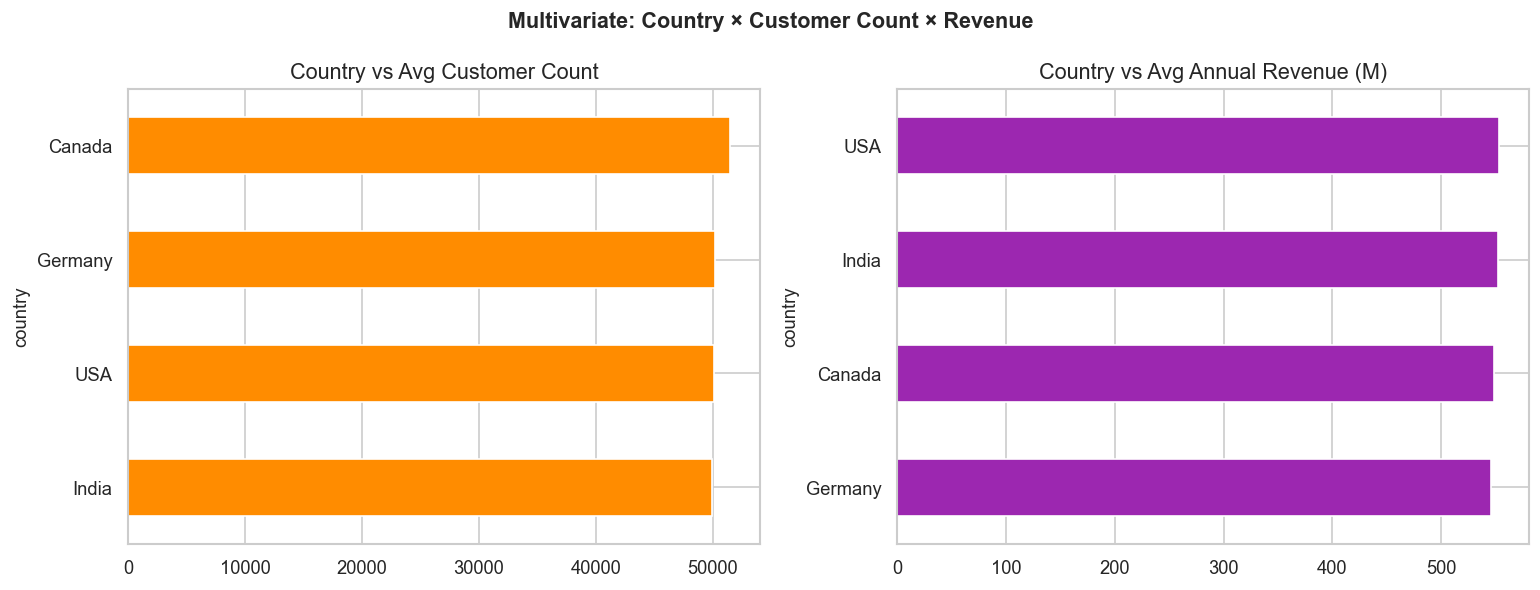

In [44]:
ountry_stats = df.groupby('country')[['customer_count', 'annual_revenue_million']].mean().round(2)
print(country_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
country_stats['customer_count'].sort_values().plot(kind='barh', ax=axes[0],
    color='darkorange', edgecolor='white')
axes[0].set_title('Country vs Avg Customer Count')

country_stats['annual_revenue_million'].sort_values().plot(kind='barh', ax=axes[1],
    color='#9C27B0', edgecolor='white')
axes[1].set_title('Country vs Avg Annual Revenue (M)')

plt.suptitle('Multivariate: Country × Customer Count × Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multivariate_country.png', bbox_inches='tight')
plt.show()


## 9. Skewness and Kurtosis Analysis

                        Skewness  Kurtosis
employee_count            0.0024   -1.1877
annual_revenue_million    0.0273   -1.1871
profit_margin_percent     0.0026   -1.2026
founded_year              0.0206   -1.1896
customer_count           -0.0049   -1.1947
market_rating            -0.0200   -1.2058



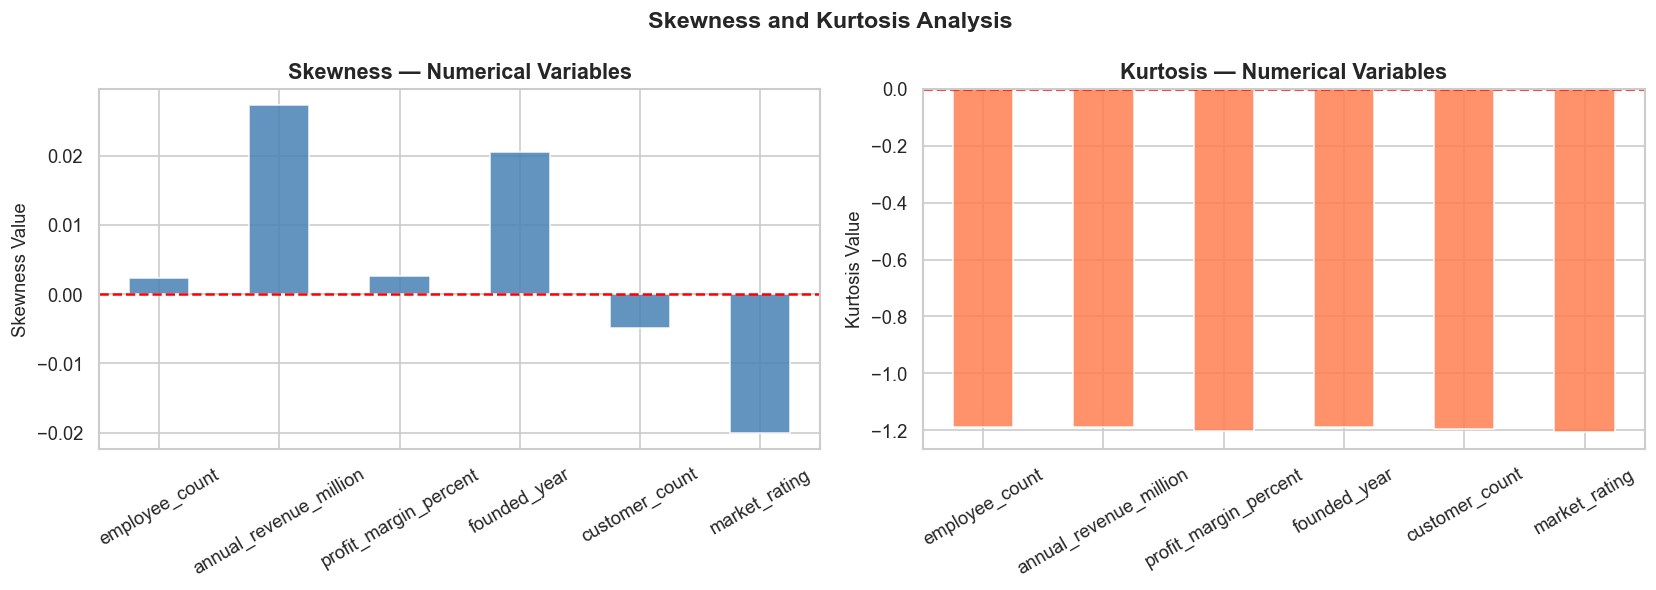

In [45]:
sk_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(4),
    'Kurtosis': df[num_cols].kurtosis().round(4)
})
print(sk_kurt)
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sk_kurt['Skewness'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Skewness — Numerical Variables', fontweight='bold')
axes[0].set_ylabel('Skewness Value')
axes[0].tick_params(axis='x', rotation=30)

sk_kurt['Kurtosis'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Kurtosis — Numerical Variables', fontweight='bold')
axes[1].set_ylabel('Kurtosis Value')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Skewness and Kurtosis Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('skewness_kurtosis.png', bbox_inches='tight')
plt.show()


## 10. Key Statistical Findings & Conclusion

### Key Findings

| Area | Insight |
|------|---------|
| **Revenue Distribution** | Near-symmetric distribution (skewness ≈ 0.027); mean revenue ~$549.7M |
| **Employee Count** | Average ~2,607 employees; ranges from 100 to 5,099 |
| **Outliers** | Detected via IQR and Z-score; retained as genuine large-scale enterprise data |
| **Technology Sector** | Consistent top performer in average annual revenue |
| **Healthcare** | Most stable profit margin across industries |
| **North America** | Highest company count (7,500 records) |
| **Correlation** | Near-zero correlations across numerical pairs — no severe multicollinearity |
| **Kurtosis** | Negative kurtosis across all variables — flatter than normal, indicating uniform spread |

### Conclusion

This project successfully applied:
- **Univariate Analysis** — Histograms, descriptive stats, skewness & kurtosis
- **Bivariate Analysis** — Scatter plots, grouped bar charts, Pearson correlation
- **Multivariate Analysis** — Cross-variable scatter plots by industry, region, country
- **Outlier Detection** — IQR method + Z-score method + Boxplots
- **Correlation Study** — Heatmap with full numerical correlation matrix

The EDA provides valuable insights for business intelligence, industry benchmarking, market trend analysis, and strategic decision-making across five industry sectors.

**Libraries Used:** NumPy, Pandas, Matplotlib, Seaborn, SciPy
